# Phase 3 — Bayesian Inversion: Time-Integrated Source Apportionment

**Prerequisite**: Run Phase 1 and Phase 2 notebooks first.

## What we're building on top of notebook 1

| Notebook 1 | Phase 3 |
|---|---|
| Single timestamp | All timestamps simultaneously |
| Flat prior (HalfNormal, same for everyone) | Fingerprint-informed prior (stations with high enrichment get higher prior) |
| No temporal structure | Hierarchical: time-windows share information |
| One T matrix | T(t) changes every 15 min |

## The Model in Plain English

```
For each 4-hour time window w:
    Q_w ~ LogNormal(μ_prior, σ_prior)    # emissions in window w, must be ≥ 0
                                          # μ_prior informed by fingerprinting

For each timestamp t in window w:
    C_predicted(t) = T(t) · Q_w          # Gaussian plume prediction
    C_observed(t)  ~ Normal(C_predicted, σ_obs)  # sensor noise

We infer: Q_w for all windows → how do emissions vary across the day?
```

**Why 4-hour windows?**  
Emissions change slowly (a factory doesn't switch on/off every 15 min).  
4 hours is a good balance: captures morning/afternoon/night patterns  
while having enough data per window for stable inference.

## MCMC Intuition (quick reminder)

We cannot solve for Q analytically because:
- LogNormal prior + Gaussian likelihood = no closed form posterior
- 14 unknowns per window × many windows = high-dimensional

MCMC (specifically NUTS in PyMC) explores the space of plausible Q values by:
1. Starting at a random Q
2. Computing how well that Q explains the observed C (via T·Q)
3. Moving to a better Q with high probability, occasionally accepting worse moves
4. After many steps, the path of Q values IS the posterior distribution

After sampling, we summarise:
- **Posterior mean**: our best estimate of Q for each station
- **90% credible interval**: the range we're 90% confident Q falls in
- **R̂ (Gelman-Rubin)**: convergence diagnostic — should be < 1.01

## Block 0 — Imports

In [ ]:
# import matplotlib.pyplot as plt
# import scienceplots
# plt.style.use(['science','no-latex'])

In [2]:
import sys
import logging
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from tqdm import tqdm
import arviz as az
import pymc as pm
import pytensor.tensor as pt
from scipy.optimize import nnls

#  Logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s  %(levelname)-8s  %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger("phase3")

#  Paths
NOTEBOOK_DIR = Path.cwd()
PHASE1_OUT = NOTEBOOK_DIR / "data_prep"
PHASE2_OUT = NOTEBOOK_DIR / "chemical_fingerprinting"
PHASE3_OUT = NOTEBOOK_DIR / "bayesian_inversion"
PHASE3_OUT.mkdir(exist_ok=True)

sys.path.insert(0, str(NOTEBOOK_DIR))

log.info("Imports OK")

11:27:46  INFO      Imports OK


## Block 1 — Load All Phase 1 & 2 Outputs

In [3]:
log.info("Loading phase 1 & 2 artefacts…")

T_tensor      = np.load(PHASE1_OUT / "T_tensor.npy")                 # (n_times, N, N)
C_wide        = pd.read_parquet(PHASE1_OUT / "C_matrix.parquet")     # (n_times, N)
meta_df       = pd.read_parquet(PHASE1_OUT / "meta.parquet")
enrichment_mat= np.load(PHASE2_OUT / "enrichment_matrix.npy")        # (N, N)

STATION_NAMES = C_wide.columns.tolist()
N             = len(STATION_NAMES)
times         = C_wide.index
n_times       = len(times)
short_names   = [s[:10] for s in STATION_NAMES]

log.info(f"Loaded: {N} stations, {n_times:,} timestamps")
log.info(f"T_tensor: {T_tensor.shape}, C_wide: {C_wide.shape}")

11:27:48  INFO      Loading phase 1 & 2 artefacts…
11:27:48  INFO      Loaded: 14 stations, 35,040 timestamps
11:27:48  INFO      T_tensor: (35040, 14, 14), C_wide: (35040, 14)


## Block 2 — Configuration

In [4]:
POLLUTANT = "pm25"

# Time windowing: we group timestamps into windows and estimate one Q per window.
# This prevents the model from overfitting to individual 15-min noisy readings.
WINDOW_HOURS = 4    # width of each time window in hours
                    # Try: 1h (fine-grained, slow), 4h (good default), 6h (coarse, fast)

# MCMC settings
N_DRAWS  = 1000     # posterior samples per chain — 1000 is enough for exploration
N_TUNE   = 500      # burn-in / adaptation steps — not included in posterior
N_CHAINS = 2        # number of independent chains — need ≥ 2 for R̂
TARGET_ACCEPT = 0.90  # NUTS acceptance rate — 0.90 gives finer step sizes
RANDOM_SEED   = 42

# Prior settings
# We use a LogNormal prior: log(Q) ~ Normal(mu_log, sigma_log)
# This enforces Q > 0 naturally (log of a positive number is anything)
PRIOR_SIGMA_LOG = 1.5   # how uncertain we are about log(Q) — larger = weaker prior
                        # sigma=1.5 in log-space means we allow Q to vary by ~exp(1.5)≈4.5x

# Scaling — normalise T and C to O(1) for better sampler geometry
# (sampler works best when parameters are order-1, not e.g. 1e-8)
USE_SCALING = True

log.info(f"Window hours    : {WINDOW_HOURS}")
log.info(f"MCMC: {N_CHAINS} chains × {N_DRAWS} draws + {N_TUNE} tune")
log.info(f"Prior sigma_log : {PRIOR_SIGMA_LOG}")

11:27:50  INFO      Window hours    : 4
11:27:50  INFO      MCMC: 2 chains × 1000 draws + 500 tune
11:27:50  INFO      Prior sigma_log : 1.5


## Block 3 — Build Fingerprint-Informed Prior Mean

Each station's prior mean for log(Q) is influenced by its empirical enrichment:
- A station that consistently enriches many receptors → likely a real source → higher prior mean
- A station with no enrichment signal → unknown source strength → neutral prior

This is the key link between Phase 2 (fingerprinting) and Phase 3 (Bayesian).

Example
|i 	|A|	B	|C|
|---|---|---|--|
|A  | -	|  1.1|	1.2|
|B 	|2.0|  	-	|1.1|
|C 	|1.8|  	1.0 |	-|

Column A:
2.0  
1.8  
Mean: 1.9  
Column B:
1.1  
1.0  
Mean: 1.05  
Interpretation:
- A tends to enrich others strongly
- B does not
So: source_score[A] > source_score[B]

/tmp/ipykernel_19172/3410944023.py:4: RuntimeWarning: Mean of empty slice
  source_score = np.nanmean(enrichment_mat, axis=0)   # (N,) one score per source station
/tmp/ipykernel_19172/3410944023.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(STATION_NAMES, rotation=45, ha="right", fontsize=8)


Fingerprint-informed prior for each source station:
Station                      Source score    mu_log_prior
----------------------------------------------------------
BTMLayout                           1.000           0.000  █████
BWSSBKadabesanahalli                1.000           0.000  █████
BapujiNagar                         1.334           0.289  ██████
CityRailwayStation                  1.000           0.000  █████
Hebbal                              0.965          -0.036  ████
HombegowdaNagar                     1.183           0.168  █████
Jayanagar5thBlock                   1.136           0.127  █████
Jigani                              1.000           0.000  █████
KasturiNagar                        0.823          -0.195  ████
Peenya                              1.000           0.000  █████
RvceMailasandra                     1.126           0.119  █████
SaneguravaHalli                     1.000           0.000  █████
ShivapuraPeenya                     1.146           

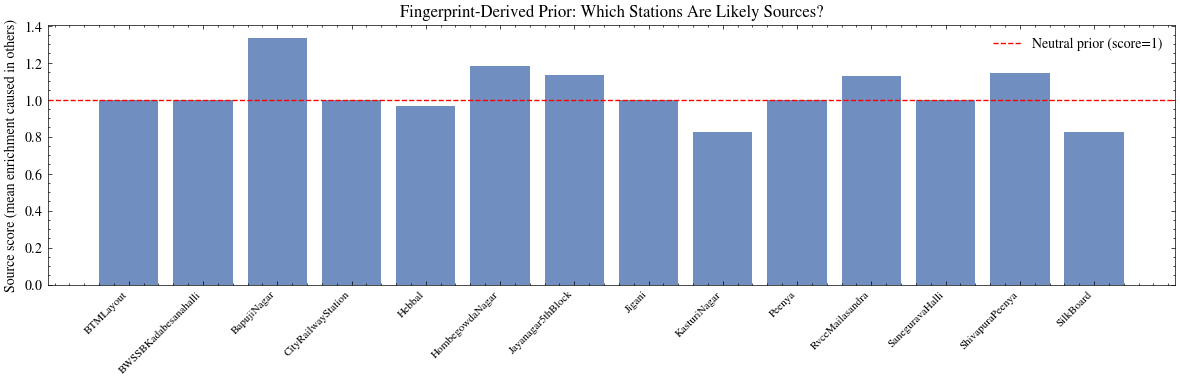

In [5]:
# For each station j, compute its 'source score' = mean enrichment it causes in others
# enrichment_mat[i, j] = how much j enriches i
# We take nanmean across all receptors i for each source j
source_score = np.nanmean(enrichment_mat, axis=0)   # (N,) one score per source station

# Replace NaN scores (insufficient data) with 1.0 = neutral
source_score = np.where(np.isnan(source_score), 1.0, source_score)

# Convert to log-scale prior mean:
# score=1.0 → mu_log=0.0 (Q~exp(0)=1 in normalised units)
# score=1.5 → mu_log=log(1.5)≈0.4 (Q is expected to be 50% higher)
mu_log_prior = np.log(source_score)   # (N,)

print("Fingerprint-informed prior for each source station:")
print(f"{'Station':25s}  {'Source score':>14}  {'mu_log_prior':>14}")
print("-" * 58)
for k, name in enumerate(STATION_NAMES):
    bar = "█" * int(source_score[k] * 5)
    print(f"{name:25s}  {source_score[k]:14.3f}  {mu_log_prior[k]:14.3f}  {bar}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(STATION_NAMES, source_score, color="#4C72B0", alpha=0.8)
ax.axhline(1.0, color="red", lw=1, ls="--", label="Neutral prior (score=1)")
ax.set_xticklabels(STATION_NAMES, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Source score (mean enrichment caused in others)")
ax.set_title("Fingerprint-Derived Prior: Which Stations Are Likely Sources?")
ax.legend()
plt.tight_layout()
plt.savefig(PHASE3_OUT / "fig_prior_source_scores.png", dpi=150, bbox_inches="tight")
plt.show()

## Block 4 — Create Time Windows

We group the timestamps into `WINDOW_HOURS`-hour blocks.
Each block will have one Q vector estimated (one emission rate per station per window).

In [6]:
# Assign each timestamp to a window index
# Strategy: floor timestamp to the nearest WINDOW_HOURS boundary
# e.g. with WINDOW_HOURS=4: 00-04h=window0, 04-08h=window1, ...

hours_arr = meta_df["hour"].values   # (n_times,)

# Window = (day_number * 24 + hour) // WINDOW_HOURS
# This gives globally unique window IDs across multiple days
days_arr  = (times - times[0]).total_seconds().values / 86400   # fractional day since start
window_id = (days_arr * 24 / WINDOW_HOURS).astype(int)           # unique window per WINDOW_HOURS block

unique_windows = np.unique(window_id)
n_windows      = len(unique_windows)

# Remap window IDs to 0..n_windows-1
window_idx = np.searchsorted(unique_windows, window_id)   # (n_times,)

log.info(f"Total timestamps: {n_times:,}")
log.info(f"Window size     : {WINDOW_HOURS}h")
log.info(f"Total windows   : {n_windows}")

# Show distribution of timestamps per window
ts_per_window = np.bincount(window_idx)
print(f"Timestamps per window — min: {ts_per_window.min()}, "
      f"median: {np.median(ts_per_window):.0f}, "
      f"max: {ts_per_window.max()}")

11:28:32  INFO      Total timestamps: 35,040
11:28:32  INFO      Window size     : 4h
11:28:32  INFO      Total windows   : 2190


Timestamps per window — min: 16, median: 16, max: 16


## Block 5 — Normalise T and C for MCMC

PyMC's NUTS sampler works best when all variables are order-1.
Raw T values can be ~1e-8 and C values can be ~100 µg/m³.
We scale both so predictions land near 1.

In [7]:
C_arr = C_wide.values.astype(np.float32)   # (n_times, N)

if USE_SCALING:
    # Scale T by its 95th percentile (robust to outlier transport events)
    T_scale = np.percentile(T_tensor[T_tensor > 0], 95)
    C_scale = np.percentile(C_arr[C_arr > 0], 95)

    T_norm = (T_tensor / T_scale).astype(np.float32)   # (n_times, N, N)
    C_norm = (C_arr   / C_scale).astype(np.float32)    # (n_times, N)

    log.info(f"T_scale = {T_scale:.4e}  |  C_scale = {C_scale:.2f}")
    log.info(f"T_norm range: [{T_norm.min():.4f}, {T_norm.max():.4f}]")
    log.info(f"C_norm range: [{C_norm.min():.4f}, {C_norm.max():.4f}]")
else:
    T_norm  = T_tensor.astype(np.float32)
    C_norm  = C_arr.astype(np.float32)
    T_scale = 1.0
    C_scale = 1.0

11:28:41  INFO      T_scale = 5.8165e+00  |  C_scale = 65.00
11:28:41  INFO      T_norm range: [0.0000, 74.3256]
11:28:41  INFO      C_norm range: [0.0000, 15.1549]


## Block 6 — Simple Bayesian Model (Single Window Baseline)

Before doing the full time-windowed model, we run the SIMPLE version first:
- Use only the FIRST time window
- Check it converges
- Make sure the math is right

This is exactly like notebook 1, but with the fingerprint-informed prior instead of flat HalfNormal.

In [ ]:
#  Select first window's data
w0_mask = window_idx == 0  # boolean mask for first window
T_w0 = T_norm[w0_mask]  # (n_ts_in_w0, N, N)
C_w0 = C_norm[w0_mask]  # (n_ts_in_w0, N)
n_ts_w0 = w0_mask.sum()

log.info(f"First window: {n_ts_w0} timestamps")

#  Build simple model
with pm.Model() as simple_model:
    # Prior on emission rates — LogNormal using fingerprint-informed mu
    # Q_j > 0 always (log-normal enforces this)
    # mu_log_prior[j]: stations that empirically enrich others get higher prior
    Q = pm.LogNormal(
        "Q",
        mu=mu_log_prior,  # (N,) fingerprint-informed
        sigma=PRIOR_SIGMA_LOG,  # scalar — same uncertainty for all
        shape=N,
    )

    # Predicted concentrations: C_pred[t, i] = sum_j T[t, i, j] * Q[j]
    # T_w0 shape: (n_ts, N, N)
    # Q shape   : (N,)
    # We want: for each t, C_pred[t] = T_w0[t] @ Q  → shape (n_ts, N)
    # pt.dot(T_w0, Q) does exactly this when T_w0 is (n_ts, N, N) and Q is (N,)
    C_pred = pt.dot(T_w0, Q)  # (n_ts_w0, N)

    # Observation noise — also inferred (not fixed)
    # HalfNormal: must be positive, 90% mass below ~2.5 * sigma=0.2 = 0.5
    sigma_obs = pm.HalfNormal("sigma_obs", sigma=0.5)

    # Likelihood: observed concentration ~ Normal(predicted, noise)
    # 'observed=C_w0' tells PyMC this is data, not a latent variable
    C_like = pm.Normal("C_obs", mu=C_pred, sigma=sigma_obs, observed=C_w0)

    # MAP estimate first — fast check before slow MCMC
    log.info("Finding MAP estimate (point estimate, fast)…")
    map_est = pm.find_MAP()
    Q_map = map_est["Q"] * (C_scale / T_scale)  # rescale back to original units

    print("\nMAP emission estimates (g/s, rescaled):")
    print(f"{'Station':25s}  {'Q_MAP':>10}")
    for k, name in enumerate(STATION_NAMES):
        print(f"{name:25s}  {Q_map[k]:10.4f}")

    # MCMC sampling
    log.info(f"Sampling: {N_CHAINS} chains × {N_DRAWS} draws + {N_TUNE} tune…")
    trace_simple = pm.sample(
        draws=N_DRAWS,
        tune=N_TUNE,
        chains=N_CHAINS,
        cores=1,  # set to 2+ if you have multiple CPUs
        target_accept=TARGET_ACCEPT,
        progressbar=True,
        return_inferencedata=True,
        random_seed=RANDOM_SEED,
    )

log.info("Sampling complete")

11:29:51  INFO      First window: 16 timestamps
11:29:51  INFO      Finding MAP estimate (point estimate, fast)…


Output()

11:29:57  INFO      Sampling: 2 chains × 1000 draws + 500 tune…
Initializing NUTS using jitter+adapt_diag...
11:29:57  INFO      Initializing NUTS using jitter+adapt_diag...



MAP emission estimates (g/s, rescaled):
Station                         Q_MAP
BTMLayout                      1.1781
BWSSBKadabesanahalli           1.1780
BapujiNagar                    0.9228
CityRailwayStation             3.0417
Hebbal                         1.1367
HombegowdaNagar                0.1111
Jayanagar5thBlock              0.1498
Jigani                         1.1780
KasturiNagar                   0.9690
Peenya                         1.1780
RvceMailasandra                1.3267
SaneguravaHalli                6.2782
ShivapuraPeenya                1.3501
SilkBoard                      0.9767


Sequential sampling (2 chains in 1 job)
11:29:59  INFO      Sequential sampling (2 chains in 1 job)
NUTS: [Q, sigma_obs]
11:29:59  INFO      NUTS: [Q, sigma_obs]


Output()

/home/srirama/micromamba/envs/pytorch/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:321: 
RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)

Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 2 seconds.
11:30:01  INFO      Sampling 2 chains for 500 tune and 1_000 draw iterations (1_000 + 2_000 draws total) took 2 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
11:30:01  INFO      We recommend running at least 4 chains for robust computation of convergence diagnostics
11:30:01  INFO      Sampling complete


## Block 7 — Convergence Diagnostics

Before trusting the results, we check that MCMC actually converged:

- **R̂ (Gelman-Rubin)**: measures if multiple chains agree. < 1.01 = good.
- **ESS (Effective Sample Size)**: how many independent samples we effectively got. > 400 = good.
- **Trace plots**: visual — chains should look like 'fuzzy caterpillars' with no trends.

In [15]:
#  R̂ and ESS table 
diag = az.summary(trace_simple, var_names=["Q"], kind="diagnostics")
print("Convergence diagnostics:")
print(diag.to_string())

# Highlight any problematic parameters
rhat_vals = diag["r_hat"].values
rhat_vals = rhat_vals.astype(float).astype(int)
bad_rhat  = rhat_vals[rhat_vals > 1.01]
if len(bad_rhat) == 0:
    print("\n✓  All R̂ < 1.01 — chains have converged.")
else:
    print(f"\n✗  {len(bad_rhat)} parameters have R̂ > 1.01 — consider more tuning steps.")

ess_vals = diag["ess_bulk"].values
bad_ess  = ess_vals[ess_vals < 400]
if len(bad_ess) == 0:
    print("✓  All ESS > 400 — sufficient effective samples.")
else:
    print(f"✗  {len(bad_ess)} parameters have ESS < 400 — consider more draws.")

Convergence diagnostics:
       ess_bulk  ess_tail r_hat mcse_mean  mcse_sd
Q[0]       2757      1535  1.01      0.26      2.1
Q[1]       3246      1696  1.00      0.15      0.6
Q[2]       3895      1343  1.00   0.00026  0.00017
Q[3]       3409      1556  1.00    0.0006  0.00043
Q[4]       3359      1489  1.00      0.17      0.7
Q[5]       2775      1477  1.00   0.00011  8.7e-05
Q[6]       3040      1384  1.00   0.00011  8.5e-05
Q[7]       3113      1517  1.00      0.17      1.8
Q[8]       2601      1607  1.00      0.17      1.4
Q[9]       3024      1485  1.00      0.18      1.2
Q[10]      2786      1617  1.00      0.18     0.86
Q[11]      3286      1266  1.00    0.0011  0.00076
Q[12]      3263      1556  1.00      0.53      9.5
Q[13]      3649      1512  1.00      0.21     0.94

✓  All R̂ < 1.01 — chains have converged.
✓  All ESS > 400 — sufficient effective samples.


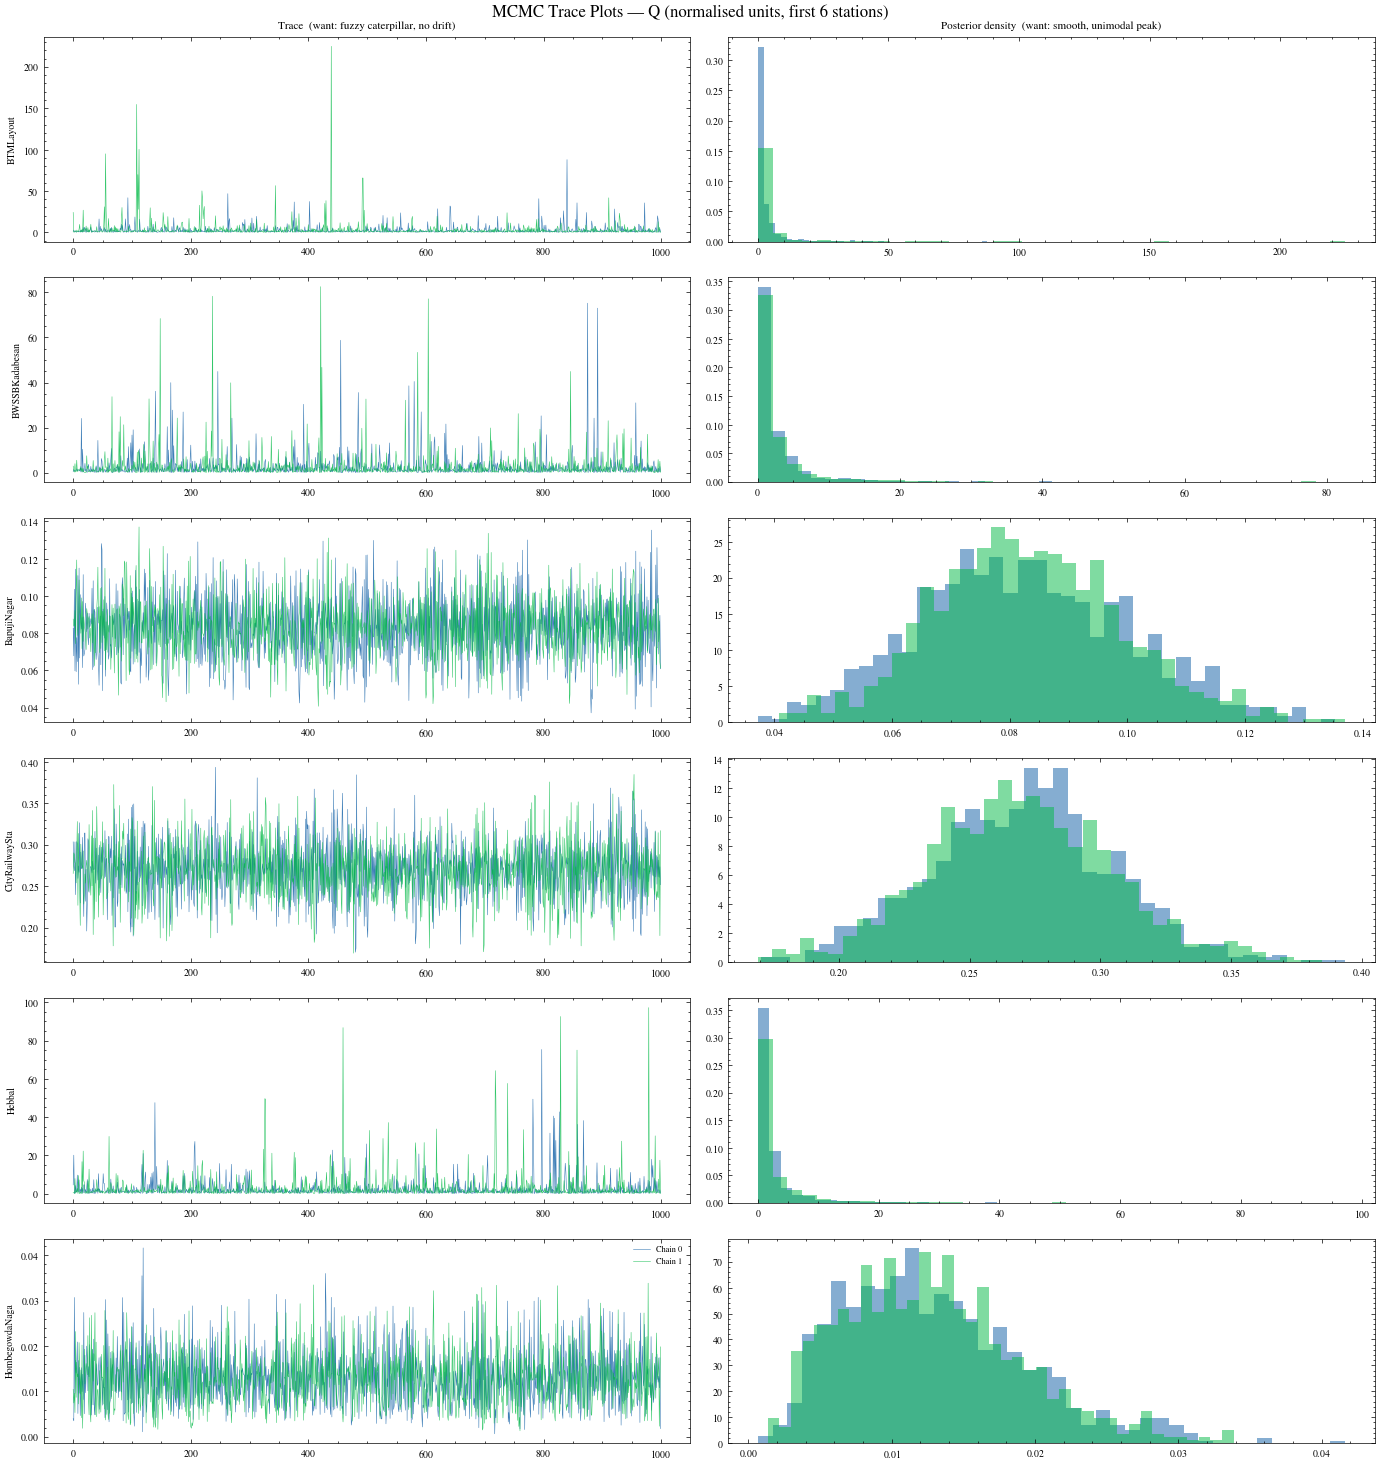

In [16]:
#  Trace plots for first 6 stations ─
# Each row: left = trace (chain trajectory), right = posterior density
# Good trace: looks like a 'fuzzy caterpillar' — no trends, no drifts

Q_post = trace_simple.posterior["Q"].values  # (chain, draw, N)
n_show = min(6, N)

fig, axes = plt.subplots(n_show, 2, figsize=(14, 2.5 * n_show))
fig.suptitle("MCMC Trace Plots — Q (normalised units, first 6 stations)", fontsize=12)

for k in range(n_show):
    samples_k = Q_post[:, :, k]  # (n_chains, n_draws)

    # Left: trace
    ax_t = axes[k, 0]
    for ch in range(samples_k.shape[0]):
        ax_t.plot(samples_k[ch], lw=0.4, alpha=0.8, label=f"Chain {ch}")
    ax_t.set_ylabel(STATION_NAMES[k][:14], fontsize=7)
    ax_t.tick_params(labelsize=7)
    if k == 0:
        ax_t.set_title("Trace  (want: fuzzy caterpillar, no drift)", fontsize=8)
    if k == n_show - 1:
        ax_t.legend(fontsize=6, loc="upper right")

    # Right: density
    ax_d = axes[k, 1]
    for ch in range(samples_k.shape[0]):
        ax_d.hist(samples_k[ch], bins=40, alpha=0.5, density=True, label=f"Chain {ch}")
    ax_d.tick_params(labelsize=7)
    if k == 0:
        ax_d.set_title("Posterior density  (want: smooth, unimodal peak)", fontsize=8)

plt.tight_layout()
plt.savefig(PHASE3_OUT / "fig_trace_simple.png", dpi=100, bbox_inches="tight")
plt.show()

## Block 8 — Visualise Posterior: Credible Intervals

The posterior gives us:
- A distribution over Q, not just a single number
- **90% credible interval**: we're 90% confident the true Q falls in this range
- Wider interval → more uncertainty (possibly fewer observations or weaker signal)

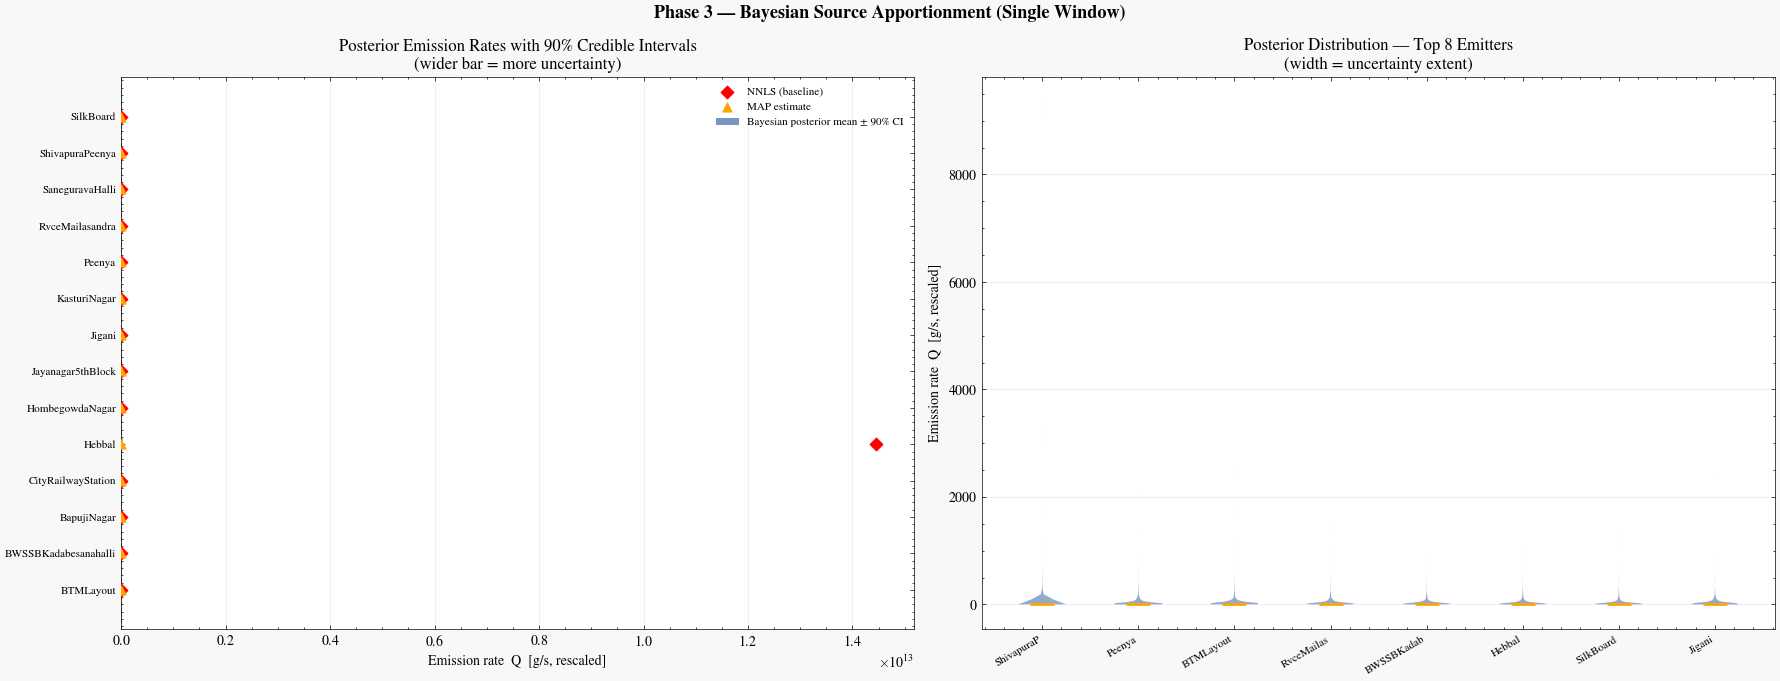

In [17]:
# Rescale posterior from normalised to original units (g/s, approximate)
Q_rescaled = Q_post * (C_scale / T_scale)  # (chain, draw, N)

Q_mean = Q_rescaled.mean(axis=(0, 1))  # (N,)
Q_lo = np.percentile(Q_rescaled, 5, axis=(0, 1))  # 5th percentile
Q_hi = np.percentile(Q_rescaled, 95, axis=(0, 1))  # 95th percentile
Q_map_rescaled = Q_map  # computed in Block 6

# Also compute NNLS baseline for comparison
T_single = T_tensor[w0_mask].mean(axis=0)  # average T over window
Q_nnls, _ = nnls(T_single, C_arr[w0_mask].mean(axis=0))

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor("#f8f8f8")

# --- Left: Posterior mean + credible interval (horizontal bar chart) ---
ax = axes[0]
y_pos = np.arange(N)
ax.barh(
    y_pos,
    Q_mean,
    xerr=[Q_mean - Q_lo, Q_hi - Q_mean],
    align="center",
    alpha=0.75,
    color="#4C72B0",
    error_kw=dict(elinewidth=1.5, capsize=4, ecolor="#2c4e80"),
    label="Bayesian posterior mean ± 90% CI",
)
ax.scatter(
    Q_nnls, y_pos, color="red", zorder=5, s=40, marker="D", label="NNLS (baseline)"
)
ax.scatter(
    Q_map_rescaled,
    y_pos,
    color="orange",
    zorder=6,
    s=40,
    marker="^",
    label="MAP estimate",
)
ax.set_yticks(y_pos)
ax.set_yticklabels(STATION_NAMES, fontsize=8)
ax.set_xlabel("Emission rate  Q  [g/s, rescaled]")
ax.set_title(
    "Posterior Emission Rates with 90% Credible Intervals\n(wider bar = more uncertainty)"
)
ax.legend(fontsize=8)
ax.grid(axis="x", alpha=0.3)
ax.axvline(0, color="gray", lw=0.8, ls="--")

# --- Right: Violin plots for top 8 by posterior mean ---
ax2 = axes[1]
top8_idx = np.argsort(Q_mean)[-8:][::-1]
data_violin = [Q_rescaled[:, :, k].flatten() for k in top8_idx]
labels_v = [STATION_NAMES[k][:10] for k in top8_idx]

parts = ax2.violinplot(
    data_violin, positions=range(len(top8_idx)), showmedians=True, showextrema=False
)
for pc in parts["bodies"]:
    pc.set_facecolor("#4C72B0")
    pc.set_alpha(0.6)
parts["cmedians"].set_color("orange")
parts["cmedians"].set_linewidth(2)

ax2.set_xticks(range(len(top8_idx)))
ax2.set_xticklabels(labels_v, rotation=30, ha="right", fontsize=8)
ax2.set_ylabel("Emission rate  Q  [g/s, rescaled]")
ax2.set_title("Posterior Distribution — Top 8 Emitters\n(width = uncertainty extent)")
ax2.grid(axis="y", alpha=0.3)

plt.suptitle(
    "Phase 3 — Bayesian Source Apportionment (Single Window)",
    fontsize=13,
    fontweight="bold",
)
plt.tight_layout()
plt.savefig(PHASE3_OUT / "fig_posterior_simple.png", dpi=150, bbox_inches="tight")
plt.show()

## Block 9 — Reconstruction Quality Check

How well does our inferred Q reproduce the observed C?
`C_predicted = T · Q_mean`  should be close to `C_observed`.
Large residuals mean the model is missing something (local sources, chemistry, etc.).

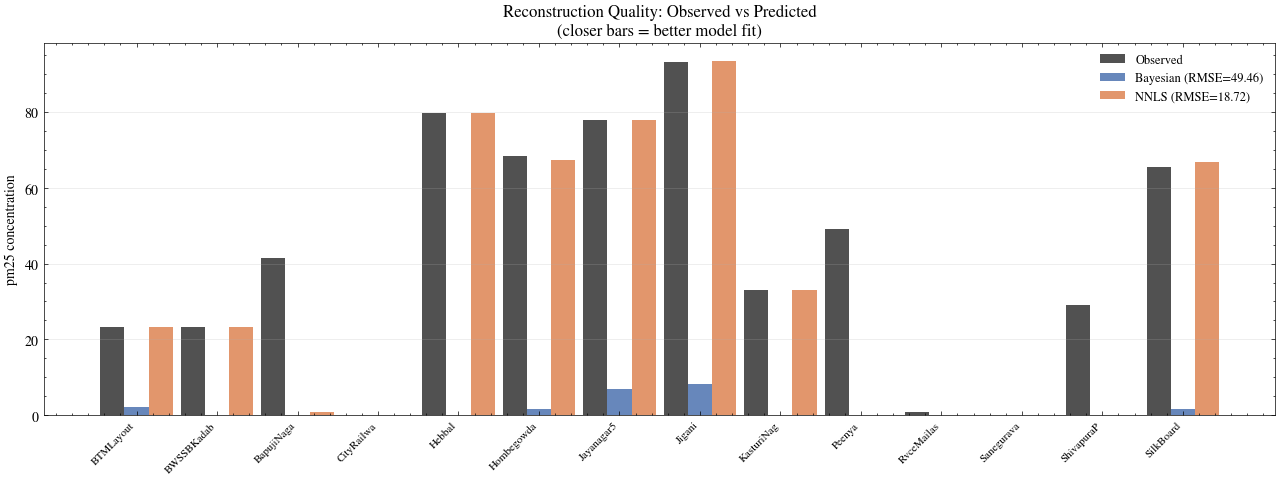

Bayesian RMSE : 49.4630
NNLS RMSE     : 18.7175


In [18]:
C_obs_w0 = C_arr[w0_mask].mean(axis=0)  # mean observed over the window
C_pred_bay = T_single @ Q_mean / (C_scale / T_scale)  # predicted from Bayesian Q_mean
C_pred_nnls = T_single @ Q_nnls

rmse_bay = np.sqrt(np.mean((C_obs_w0 - C_pred_bay) ** 2))
rmse_nnls = np.sqrt(np.mean((C_obs_w0 - C_pred_nnls) ** 2))

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(N)
w = 0.3
ax.bar(x - w, C_obs_w0, width=w, label="Observed", alpha=0.85, color="#333")
ax.bar(
    x,
    C_pred_bay,
    width=w,
    label=f"Bayesian (RMSE={rmse_bay:.2f})",
    alpha=0.85,
    color="#4C72B0",
)
ax.bar(
    x + w,
    C_pred_nnls,
    width=w,
    label=f"NNLS (RMSE={rmse_nnls:.2f})",
    alpha=0.85,
    color="#DD8452",
)

ax.set_xticks(x)
ax.set_xticklabels(short_names, rotation=45, ha="right", fontsize=8)
ax.set_ylabel(f"{POLLUTANT} concentration")
ax.set_title(
    "Reconstruction Quality: Observed vs Predicted\n(closer bars = better model fit)"
)
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(PHASE3_OUT / "fig_reconstruction.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Bayesian RMSE : {rmse_bay:.4f}")
print(f"NNLS RMSE     : {rmse_nnls:.4f}")

## Block 10 — Time-Windowed Bayesian: Q Across All Windows

Now we run the FULL version: estimate Q for EVERY time window.

**Strategy**: Run MCMC independently per window (embarrassingly parallel, but we do it sequentially).
For large datasets, this is more practical than one giant hierarchical model.

**Output**: `Q_time_mean[w, j]` = mean emission of station j in window w

> ⚠️ **Time warning**: This will take n_windows × ~30s = many minutes.
> For exploration, set `MAX_WINDOWS` below to run only a sample.

In [19]:
# Limit to first MAX_WINDOWS for fast exploration
# Set to n_windows to run all (slow!)
MAX_WINDOWS = min(24, n_windows)  # 24 windows = 1 day at 1h, or 4 days at 4h

log.info(f"Running windowed Bayesian for {MAX_WINDOWS}/{n_windows} windows…")

# Storage
Q_time_mean = np.full((MAX_WINDOWS, N), np.nan)
Q_time_lo = np.full((MAX_WINDOWS, N), np.nan)
Q_time_hi = np.full((MAX_WINDOWS, N), np.nan)

for w in tqdm(range(MAX_WINDOWS), desc="Time windows"):
    mask = window_idx == w
    n_ts_w = mask.sum()

    if n_ts_w < 2:  # not enough data in this window
        continue

    T_w = T_norm[mask]  # (n_ts_w, N, N)
    C_w = C_norm[mask]  # (n_ts_w, N)

    try:
        with pm.Model():
            Q_w = pm.LogNormal("Q", mu=mu_log_prior, sigma=PRIOR_SIGMA_LOG, shape=N)
            C_pred_w = pt.dot(T_w, Q_w)  # (n_ts_w, N)
            sigma_obs_w = pm.HalfNormal("sigma_obs", sigma=0.5)
            pm.Normal("C_obs", mu=C_pred_w, sigma=sigma_obs_w, observed=C_w)

            trace_w = pm.sample(
                draws=500,  # fewer draws per window for speed
                tune=250,
                chains=2,
                cores=1,
                target_accept=TARGET_ACCEPT,
                progressbar=False,  # suppress per-window progress bars
                return_inferencedata=True,
                random_seed=RANDOM_SEED + w,
            )

        Q_post_w = trace_w.posterior["Q"].values * (C_scale / T_scale)  # rescale
        Q_time_mean[w] = Q_post_w.mean(axis=(0, 1))
        Q_time_lo[w] = np.percentile(Q_post_w, 5, axis=(0, 1))
        Q_time_hi[w] = np.percentile(Q_post_w, 95, axis=(0, 1))

    except Exception as e:
        log.warning(f"Window {w} failed: {e}")

log.info("Windowed Bayesian complete")

11:32:54  INFO      Running windowed Bayesian for 24/2190 windows…
Time windows:   0%|          | 0/24 [00:00<?, ?it/s]Initializing NUTS using jitter+adapt_diag...
11:32:54  INFO      Initializing NUTS using jitter+adapt_diag...
Sequential sampling (2 chains in 1 job)
11:32:54  INFO      Sequential sampling (2 chains in 1 job)
NUTS: [Q, sigma_obs]
11:32:54  INFO      NUTS: [Q, sigma_obs]
/home/srirama/micromamba/envs/pytorch/lib/python3.12/site-packages/pymc/step_methods/hmc/quadpotential.py:321: RuntimeWarning: overflow encountered in dot
  return 0.5 * np.dot(x, v_out)
Sampling 2 chains for 250 tune and 500 draw iterations (500 + 1_000 draws total) took 1 seconds.
11:32:55  INFO      Sampling 2 chains for 250 tune and 500 draw iterations (500 + 1_000 draws total) took 1 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
11:32:55  INFO      We recommend running at least 4 chains for robust computation of convergence diagnostics
Time windo

## Block 11 — Visualise Time-Varying Emissions

Now we can answer: **How do station emissions change across the day?**

This is the core result of the time-varying analysis.

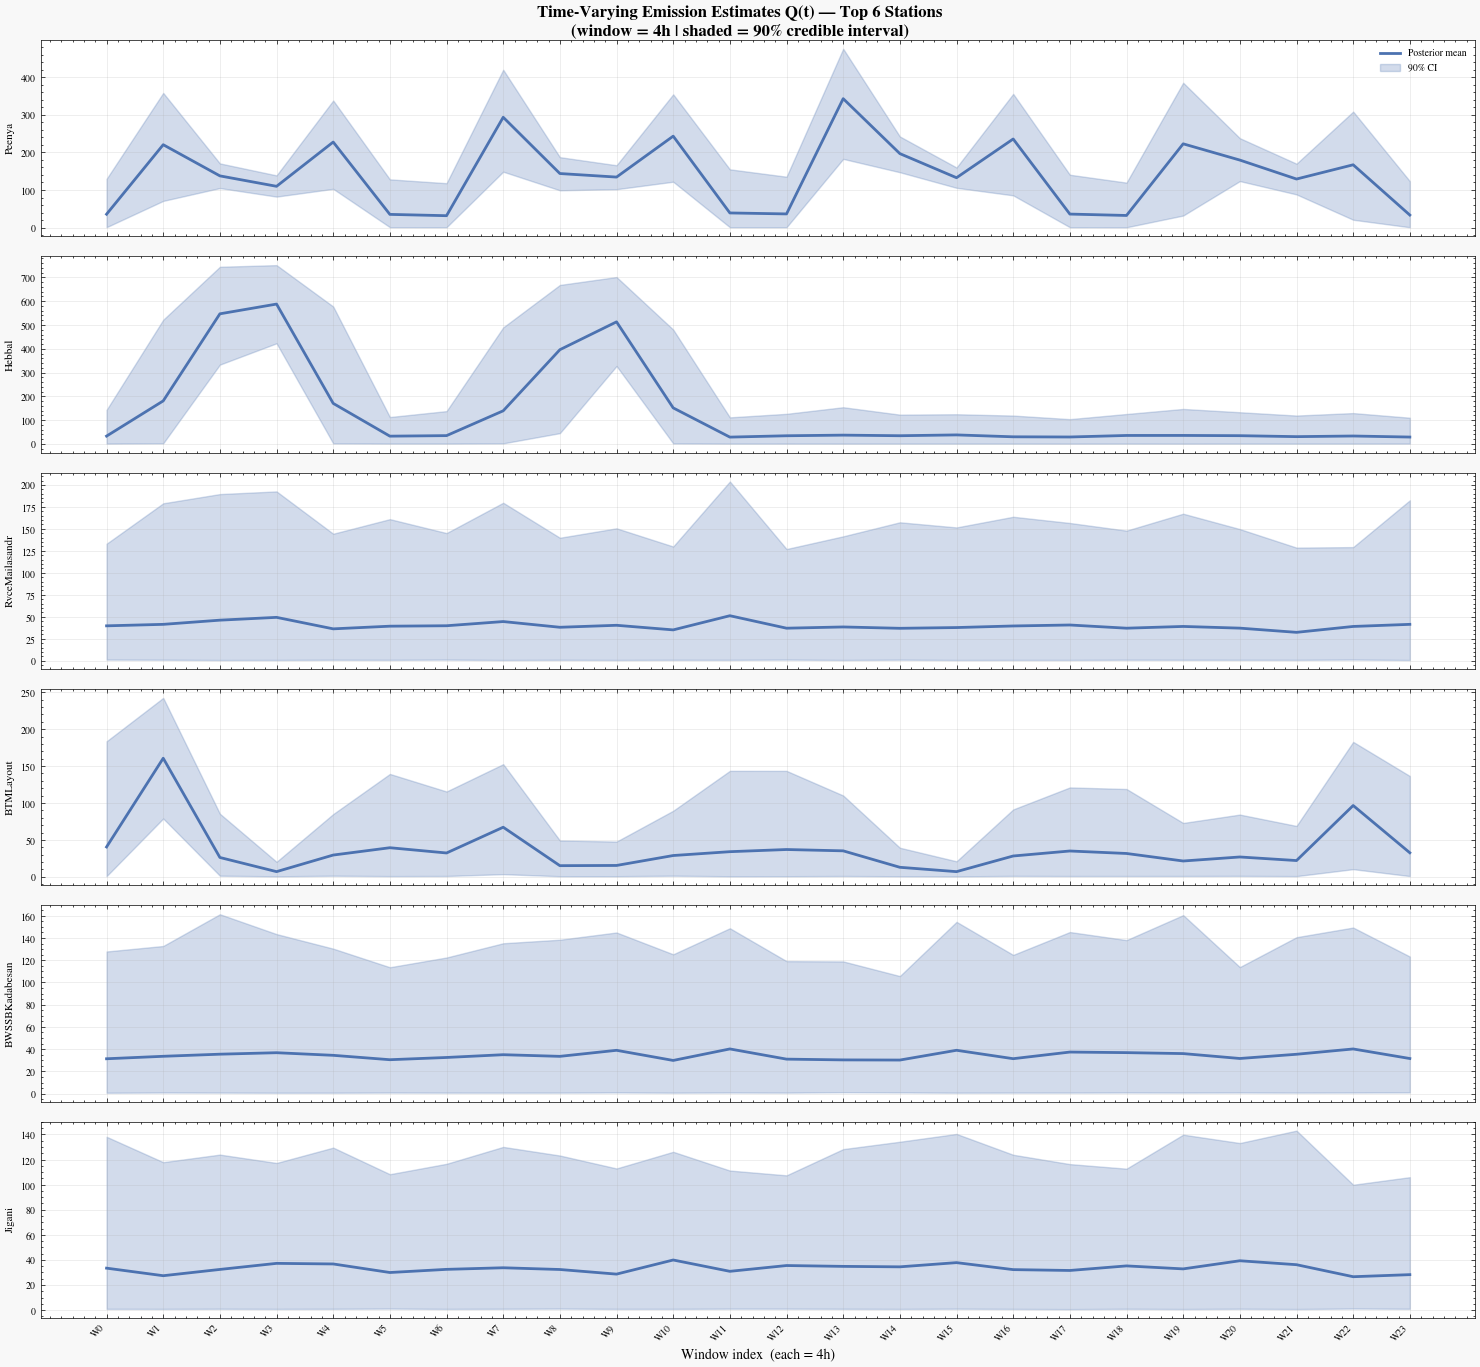

In [20]:
# Window start times (for x-axis labels)
window_start_times = [
    times[window_idx == w][0] if (window_idx == w).sum() > 0 else pd.NaT
    for w in range(MAX_WINDOWS)
]

#  Figure: Time series of Q for each station ─
# Plot top 6 stations by mean emission over the analysis period
mean_Q_overall = np.nanmean(Q_time_mean, axis=0)  # (N,)
top6_idx = np.argsort(mean_Q_overall)[-6:][::-1]

fig, axes = plt.subplots(6, 1, figsize=(15, 14), sharex=True)
fig.patch.set_facecolor("#f8f8f8")
fig.suptitle(
    f"Time-Varying Emission Estimates Q(t) — Top 6 Stations\n"
    f"(window = {WINDOW_HOURS}h | shaded = 90% credible interval)",
    fontsize=12,
    fontweight="bold",
)

x_vals = np.arange(MAX_WINDOWS)
for row, k in enumerate(top6_idx):
    ax = axes[row]
    mean_k = Q_time_mean[:, k]
    lo_k = Q_time_lo[:, k]
    hi_k = Q_time_hi[:, k]

    ax.plot(x_vals, mean_k, color="#4C72B0", lw=2, label="Posterior mean")
    ax.fill_between(x_vals, lo_k, hi_k, alpha=0.25, color="#4C72B0", label="90% CI")
    ax.set_ylabel(STATION_NAMES[k][:14], fontsize=8)
    ax.grid(alpha=0.3)
    ax.tick_params(labelsize=7)

    if row == 0:
        ax.legend(fontsize=7, loc="upper right")

# X-axis: window indices (or time labels if available)
axes[-1].set_xlabel(f"Window index  (each = {WINDOW_HOURS}h)")

# Add hour labels on x-axis for first 24h
if MAX_WINDOWS <= 48:
    hour_labels = [f"W{w}" for w in range(MAX_WINDOWS)]
    axes[-1].set_xticks(x_vals)
    axes[-1].set_xticklabels(hour_labels, rotation=45, ha="right", fontsize=7)

plt.tight_layout()
plt.savefig(PHASE3_OUT / "fig_time_varying_Q.png", dpi=150, bbox_inches="tight")
plt.show()

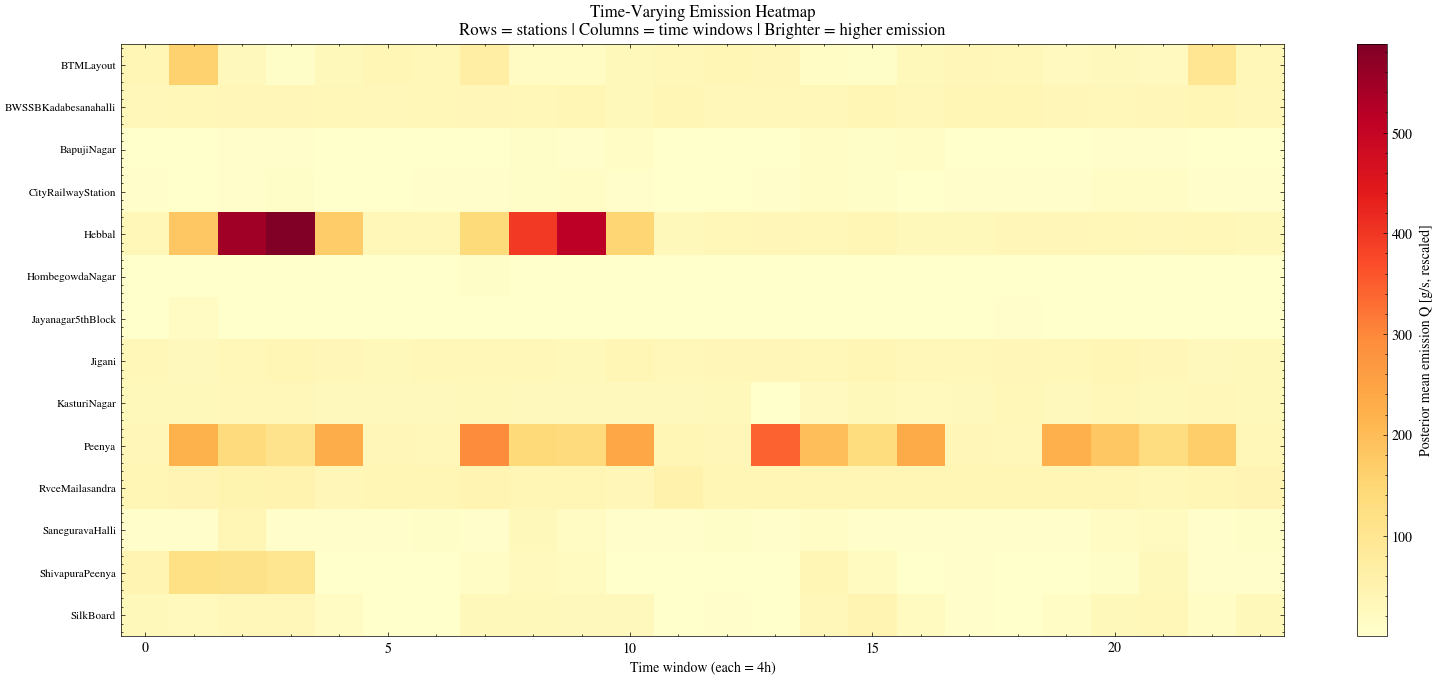

In [21]:
#  Heatmap: Q_time_mean as (station × window) ─
# This is the most information-dense summary of Phase 3.
# Each row = one station, each column = one time window.
# Bright = high emission, dark = low emission.

fig, ax = plt.subplots(figsize=(16, 7))
im = ax.imshow(
    Q_time_mean.T,  # transpose: rows=stations, cols=windows
    aspect="auto",
    cmap="YlOrRd",
    interpolation="nearest",
)
plt.colorbar(im, ax=ax, label="Posterior mean emission Q [g/s, rescaled]")
ax.set_yticks(range(N))
ax.set_yticklabels(STATION_NAMES, fontsize=8)
ax.set_xlabel(f"Time window (each = {WINDOW_HOURS}h)")
ax.set_title(
    "Time-Varying Emission Heatmap\n"
    "Rows = stations | Columns = time windows | Brighter = higher emission"
)
plt.tight_layout()
plt.savefig(PHASE3_OUT / "fig_Q_heatmap_time.png", dpi=150, bbox_inches="tight")
plt.show()

## Block 12 — Export Results

In [22]:
# Save windowed Q estimates
np.save(PHASE3_OUT / "Q_time_mean.npy", Q_time_mean)
np.save(PHASE3_OUT / "Q_time_lo.npy", Q_time_lo)
np.save(PHASE3_OUT / "Q_time_hi.npy", Q_time_hi)

# Also save as a readable CSV: rows=windows, cols=stations
Q_df = pd.DataFrame(Q_time_mean, columns=STATION_NAMES)
Q_df.to_csv(PHASE3_OUT / "Q_time_mean.csv", index=True)

# Summary table: overall mean and CI
summary_df = pd.DataFrame(
    {
        "station": STATION_NAMES,
        "Q_overall_mean": np.nanmean(Q_time_mean, axis=0),
        "Q_overall_lo": np.nanmean(Q_time_lo, axis=0),
        "Q_overall_hi": np.nanmean(Q_time_hi, axis=0),
        "source_score": source_score,
    }
).sort_values("Q_overall_mean", ascending=False)

summary_df.to_csv(PHASE3_OUT / "source_apportionment_summary.csv", index=False)

print("\n" + "=" * 65)
print("PHASE 3 FINAL SUMMARY — SOURCE APPORTIONMENT")
print("=" * 65)
display(summary_df.to_string(index=False))
print("=" * 65)
print("\nAll Phase 3 outputs saved to:", PHASE3_OUT)
print("\nNext steps:")
print("  → Phase 4: Seasonal decomposition & Kalman filter  (4_temporal.ipynb)")
print("  → Cross-validate: compare Q rankings with emission inventory data")
print("  → Sensitivity: try different CONE_DEG, WINDOW_HOURS, PRIOR_SIGMA_LOG")


PHASE 3 FINAL SUMMARY — SOURCE APPORTIONMENT


'             station  Q_overall_mean  Q_overall_lo  Q_overall_hi  source_score\n              Peenya      141.527124     67.801720    230.014779      1.000000\n              Hebbal      133.761842     48.000615    289.833003      0.964918\n     RvceMailasandra       39.942464      1.090704    156.369548      1.126198\n           BTMLayout       36.786717      4.784195    106.052886      1.000000\nBWSSBKadabesanahalli       34.314869      0.940301    134.157019      1.000000\n              Jigani       33.328591      0.989323    122.517026      1.000000\n        KasturiNagar       26.810504      0.743834    101.778390      0.822553\n     ShivapuraPeenya       22.828152     13.138266     35.535234      1.146068\n           SilkBoard       19.284368      0.678498     73.432770      0.827497\n     SaneguravaHalli        9.825601      3.621638     17.513183      1.000000\n  CityRailwayStation        4.984925      3.204114      6.764183      1.000000\n         BapujiNagar        3.545540   


All Phase 3 outputs saved to: /home/srirama/Documents/sr_proj/AirModeling/backend/tests/notebooks/bayesian_inversion

Next steps:
  → Phase 4: Seasonal decomposition & Kalman filter  (4_temporal.ipynb)
  → Cross-validate: compare Q rankings with emission inventory data
  → Sensitivity: try different CONE_DEG, WINDOW_HOURS, PRIOR_SIGMA_LOG
